In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("Clean Financial_Data table.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [32]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

In [11]:
#Total Revenue
total_sales = df["Sales"].sum()
print("Total Revenue:", total_sales)
#Total Profit
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)
#Total Quantity
total_quantity = df["Quantity"].sum()
print("Total Quantity:", total_quantity)
#Profit Margin
profit_margin = (total_profit / total_sales) * 100
print("Profit Margin:", profit_margin)
#Average Order Value
orders = df["Order ID"].nunique()
aov = total_sales / orders
print("Average Order Value:", aov)

Total Revenue: 2297200.8603000003
Total Profit: 286397.0217
Total Quantity: 37873
Profit Margin: 12.467217240315604
Average Order Value: 458.61466566180883


In [15]:
#1. Monthly Revenue
monthly_sales = df.groupby("Month_Name")["Sales"].sum()
monthly_sales

Month_Name
April        147031.2641
August       209964.3679
December     248765.3272
February     132721.3594
January      161083.5874
July         161227.1045
June         144883.4973
March        220064.6460
May          166420.3167
November     271693.7525
October      184356.3342
September    248989.3031
Name: Sales, dtype: float64

In [16]:
#2. Monthly Profit
monthly_profit = df.groupby("Month_Name")["Profit"].sum()
monthly_profit

Month_Name
April        12267.1962
August       24820.3450
December     32317.2985
February     23753.6477
January      25167.1017
July         10008.6488
June         21164.9016
March        29336.5893
May          24234.4105
November     26435.0796
October      22336.9254
September    34554.8774
Name: Profit, dtype: float64

In [17]:
#3. Region-wise Revenue
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [18]:
#4. Region-wise Profit
df.groupby("Region")["Profit"].sum().sort_values(ascending=False)  

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

In [19]:
#5. Category Performance
df.groupby("Category")[["Sales", "Profit"]].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [20]:
#6. Sub-Category Performance
df.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
Sub-Category,,
Copiers,149528.0300,55617.8249
Phones,330007.0540,44515.7306
Accessories,167380.3180,41936.6357
Paper,78479.2060,34053.5693
Binders,203412.7330,30221.7633
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Appliances,107532.1610,18138.0054
Furnishings,91705.1640,13059.1436


In [23]:
#7. Top 10 Products
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [24]:
#8. Loss-Making Products
df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [25]:
#9. Discount vs Profit
df[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [28]:
#10. Segment Performance
segment = df.groupby("Segment")[["Sales", "Profit"]].sum()

segment["Profit Margin"] = (
    segment["Profit"] / segment["Sales"] * 100
)

segment["Sales"] = segment["Sales"].round(0).astype(int)
segment["Profit"] = segment["Profit"].round(0).astype(int)

segment

,Sales,Profit,Profit Margin
Segment,,,
Consumer,1161401,134119,11.548050
Corporate,706146,91979,13.025506
Home Office,429653,60299,14.034269


6. Python Visualizations

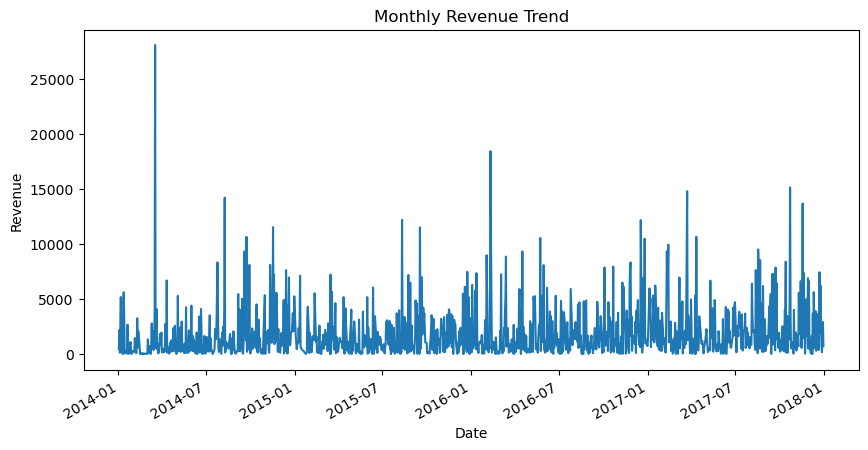

In [29]:
#Revenue Trend
monthly = df.groupby("Order Date")["Sales"].sum()

monthly.plot(kind="line", figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

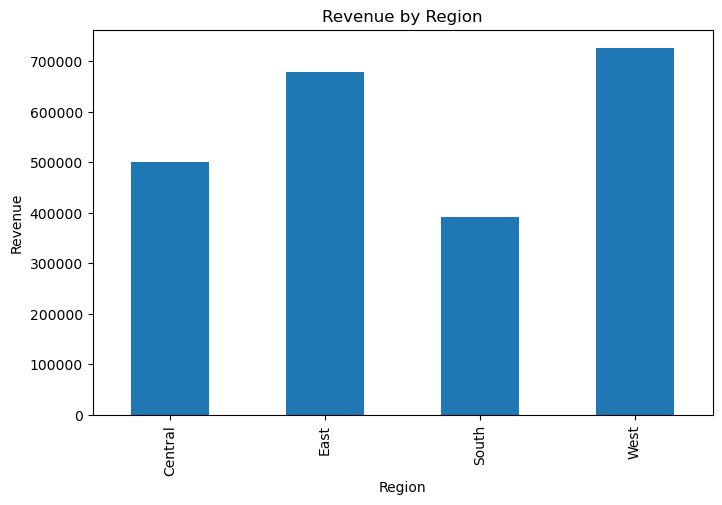

In [30]:
#Region Sales
region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

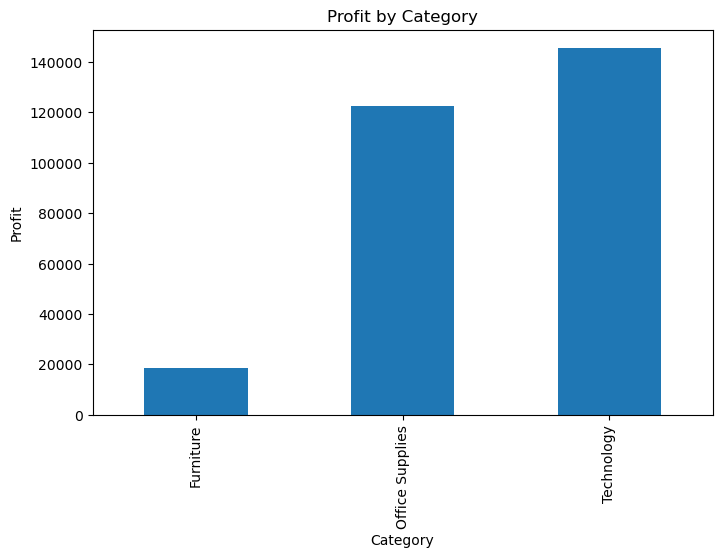

In [31]:
#Category Profit
category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar", figsize=(8,5))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

In [35]:
df.to_excel("Financial_Analytics_Final.xlsx", index=False)